##Install Libraries

In [20]:
%%capture
!pip install -q langchain-groq pandas

##API Key Configuration

In [21]:
from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

##Initialize GROQ

In [22]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

##RAG Dataset

In [23]:
samples = [
    {
        "question": "What is FAISS?",
        "context": """
        FAISS is an open-source library developed by Meta for efficient
        similarity search and clustering of dense vectors.
        """,
        "answer": """
        FAISS is a library used for efficient similarity search among vectors.
        """
    },
    {
        "question": "What is BM25?",
        "context": """
        BM25 is a probabilistic ranking algorithm used in information retrieval
        and search engines.
        """,
        "answer": """
        BM25 is a ranking function used by search engines to determine document relevance.
        """
    }
]

##Context Relevance Evaluation

In [24]:
def evaluate_context_relevance(question, context):

    prompt = f"""
You are an evaluator.

Question:
{question}

Retrieved Context:
{context}

Rate the context relevance from 1 to 5.

Scoring:
1 = Irrelevant
2 = Slightly Relevant
3 = Moderately Relevant
4 = Relevant
5 = Highly Relevant

Return ONLY a number.
"""

    response = llm.invoke(prompt)
    return response.content.strip()

Answer Relevenace Evaluation

In [25]:
def evaluate_answer_relevance(question, answer):

    prompt = f"""
You are an evaluator.

Question:
{question}

Answer:
{answer}

Rate answer relevance from 1 to 5.

Scoring:
1 = Poor
2 = Weak
3 = Average
4 = Good
5 = Excellent

Return ONLY a number.
"""

    response = llm.invoke(prompt)
    return response.content.strip()

##Groundedness Evaluation

In [26]:
def evaluate_groundedness(context, answer):

    prompt = f"""
You are a hallucination detector.

Context:
{context}

Answer:
{answer}

Determine whether the answer is fully supported by the context.

Rate from 1 to 5.

1 = Completely unsupported
2 = Mostly unsupported
3 = Partially supported
4 = Mostly supported
5 = Fully supported

Return ONLY a number.
"""

    response = llm.invoke(prompt)
    return response.content.strip()

##Run Evaluation

In [27]:
results = []

for item in samples:

    context_score = evaluate_context_relevance(
        item["question"],
        item["context"]
    )

    answer_score = evaluate_answer_relevance(
        item["question"],
        item["answer"]
    )

    groundedness_score = evaluate_groundedness(
        item["context"],
        item["answer"]
    )

    results.append({
        "Question": item["question"],
        "Context Relevance": context_score,
        "Answer Relevance": answer_score,
        "Groundedness": groundedness_score
    })

##Results

In [28]:
import pandas as pd

df = pd.DataFrame(results)

df

,Question,Context Relevance,Answer Relevance,Groundedness
0,What is FAISS?,5,5,4
1,What is BM25?,5,4,5


##Visualize

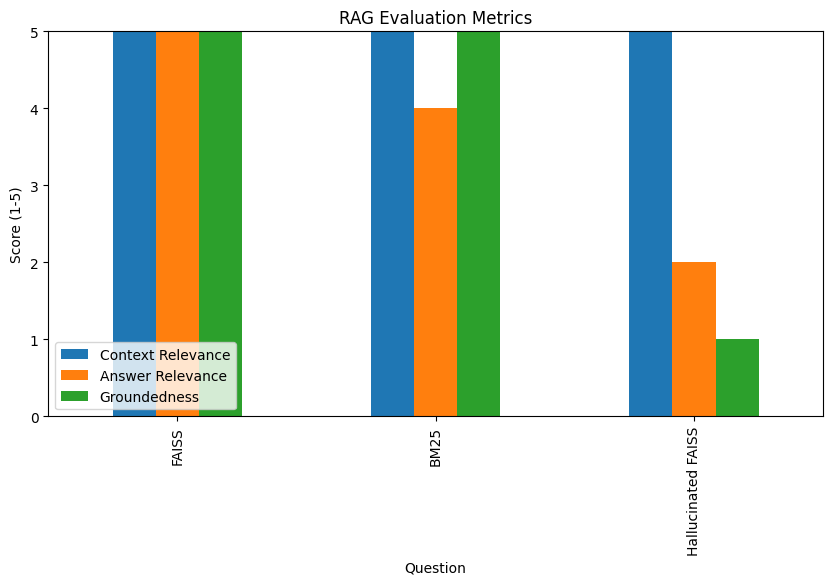

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Question": ["FAISS", "BM25", "Hallucinated FAISS"],
    "Context Relevance": [5, 5, 5],
    "Answer Relevance": [5, 4, 2],
    "Groundedness": [5, 5, 1]
})

ax = df.set_index("Question").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("RAG Evaluation Metrics")
plt.ylabel("Score (1-5)")
plt.ylim(0,5)
plt.legend(loc="lower left")
plt.show()

##Hallucinated Example

In [30]:
samples.append(
    {
        "question": "What is FAISS?",
        "context": """
        FAISS is a similarity search library developed by Meta.
        """,
        "answer": """
        FAISS was created by Google in 2024 and supports quantum databases.
        """
    }
)

In [31]:
results = []

for item in samples:

    context_score = evaluate_context_relevance(
        item["question"],
        item["context"]
    )

    answer_score = evaluate_answer_relevance(
        item["question"],
        item["answer"]
    )

    groundedness_score = evaluate_groundedness(
        item["context"],
        item["answer"]
    )

    results.append({
        "Question": item["question"],
        "Context Relevance": context_score,
        "Answer Relevance": answer_score,
        "Groundedness": groundedness_score
    })

In [32]:
import pandas as pd

df = pd.DataFrame(results)

df

,Question,Context Relevance,Answer Relevance,Groundedness
0,What is FAISS?,5,5,4
1,What is BM25?,5,4,5
2,What is FAISS?,5,1,1


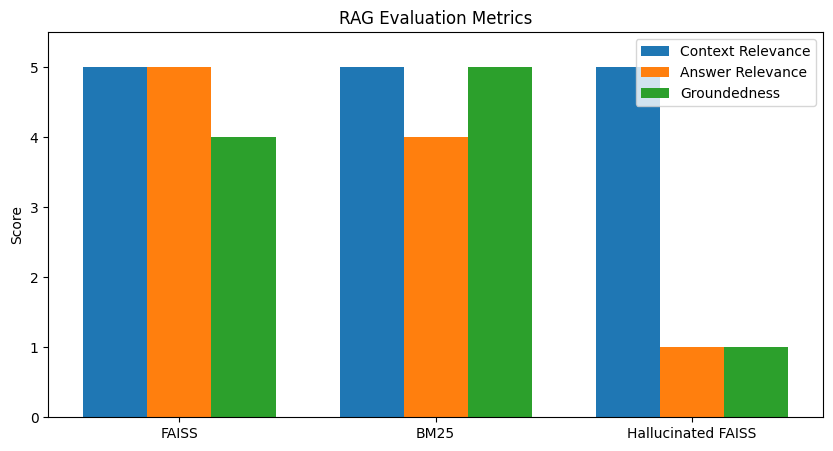

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame({
    "Question": [
        "FAISS",
        "BM25",
        "Hallucinated FAISS"
    ],
    "Context Relevance": [5, 5, 5],
    "Answer Relevance": [5, 4, 1],
    "Groundedness": [4, 5, 1]
})

x = np.arange(len(df))
width = 0.25

fig, ax = plt.subplots(figsize=(10,5))

ax.bar(x - width, df["Context Relevance"], width,
       label="Context Relevance")

ax.bar(x, df["Answer Relevance"], width,
       label="Answer Relevance")

ax.bar(x + width, df["Groundedness"], width,
       label="Groundedness")

ax.set_ylabel("Score")
ax.set_title("RAG Evaluation Metrics")
ax.set_xticks(x)
ax.set_xticklabels(df["Question"])
ax.set_ylim(0, 5.5)
ax.legend()

plt.show()